<a href="https://colab.research.google.com/github/nuha18/SAM-AI-Tech-Internship/blob/main/Task_5(CarPricePrediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('car data.csv')

In [4]:
print(df.head(10))

        Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0           ritz  2014           3.35           5.59       27000    Petrol   
1            sx4  2013           4.75           9.54       43000    Diesel   
2           ciaz  2017           7.25           9.85        6900    Petrol   
3        wagon r  2011           2.85           4.15        5200    Petrol   
4          swift  2014           4.60           6.87       42450    Diesel   
5  vitara brezza  2018           9.25           9.83        2071    Diesel   
6           ciaz  2015           6.75           8.12       18796    Petrol   
7        s cross  2015           6.50           8.61       33429    Diesel   
8           ciaz  2016           8.75           8.89       20273    Diesel   
9           ciaz  2015           7.45           8.92       42367    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual   

In [5]:
print(df.shape)

(301, 9)


In [6]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [7]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [8]:
print(df.dtypes)

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object


In [9]:
print(df.describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [10]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(5))


Car_Name — 98 unique values:
Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
Name: count, dtype: int64

Fuel_Type — 3 unique values:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type — 2 unique values:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission — 2 unique values:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [11]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f"\nClean dataset shape: {df.shape}")


Clean dataset shape: (299, 9)


**Feature Engineering**

In [12]:
#Extract Brand from Car_Name
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()

print("\nTop car brands:")
print(df['Brand'].value_counts().head(10))


Top car brands:
Brand
city        26
bajaj       25
corolla     17
royal       17
honda       17
hero        15
verna       14
etios       11
fortuner    10
brio        10
Name: count, dtype: int64


In [13]:
#Car_Age
df['Car_Age'] = 2026 - df['Year']

In [14]:
#Depreciation (how much value lost from showroom price)
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

In [15]:
#Price per km driven (value efficiency)
df['Price_per_km'] = df['Selling_Price'] / (df['Driven_kms'] + 1)

In [16]:
#Drop columns we no longer need
df.drop(columns=['Car_Name', 'Year'], inplace=True)

In [17]:
print("\nColumns after feature engineering:")
print(df.columns.tolist())


Columns after feature engineering:
['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Brand', 'Car_Age', 'Depreciation', 'Price_per_km']


**Exploratory Data Analysis**

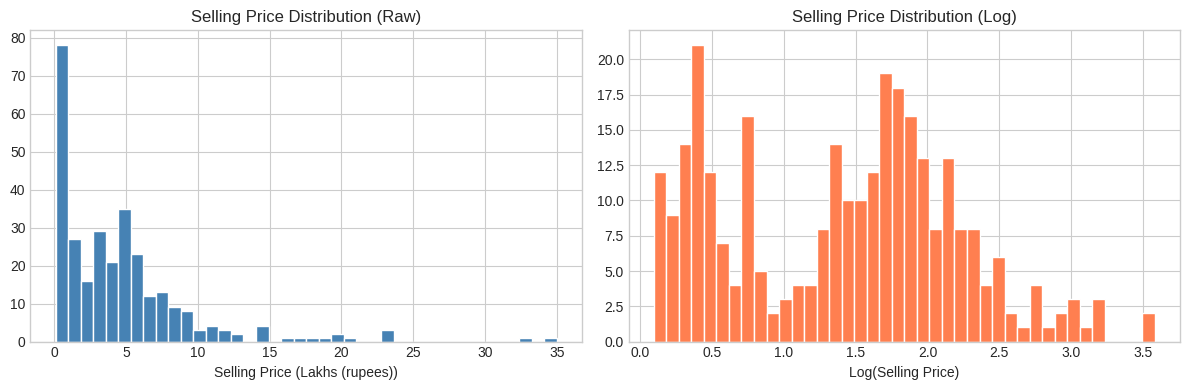

In [18]:
#Distribution of Selling Price
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Selling_Price'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Selling Price Distribution (Raw)')
plt.xlabel('Selling Price (Lakhs (rupees))')

plt.subplot(1, 2, 2)
np.log1p(df['Selling_Price']).hist(bins=40, color='coral', edgecolor='white')
plt.title('Selling Price Distribution (Log)')
plt.xlabel('Log(Selling Price)')

plt.tight_layout()
plt.show()

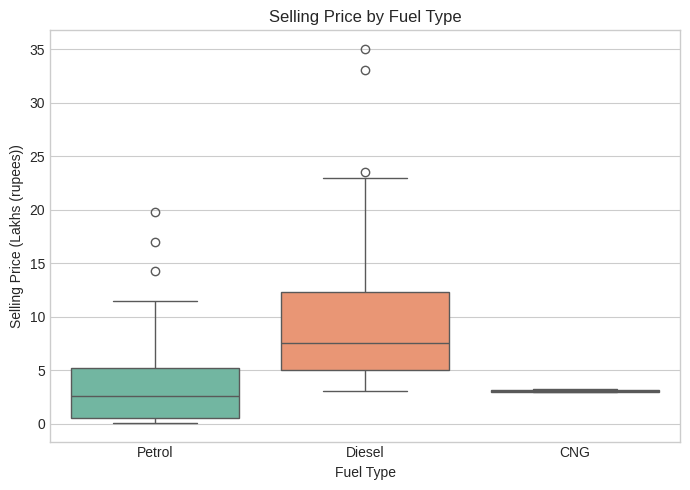

In [19]:
#Selling Price by Fuel Type
plt.figure(figsize=(7, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2', legend=False, hue='Fuel_Type')
plt.xticks(rotation=0)
plt.xlabel('Fuel Type')
plt.title('Selling Price by Fuel Type')
plt.ylabel('Selling Price (Lakhs (rupees))')
plt.tight_layout()
plt.show()

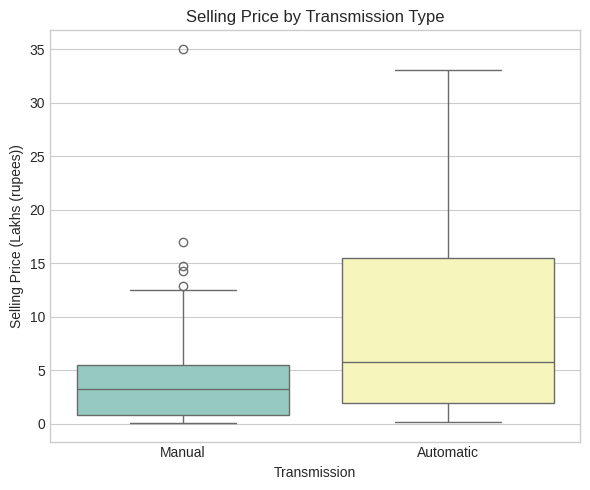

In [20]:
#Selling Price by Transmission
plt.figure(figsize=(6, 5))
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set3', hue='Transmission')
plt.title('Selling Price by Transmission Type')
plt.ylabel('Selling Price (Lakhs (rupees))')
plt.tight_layout()
plt.show()

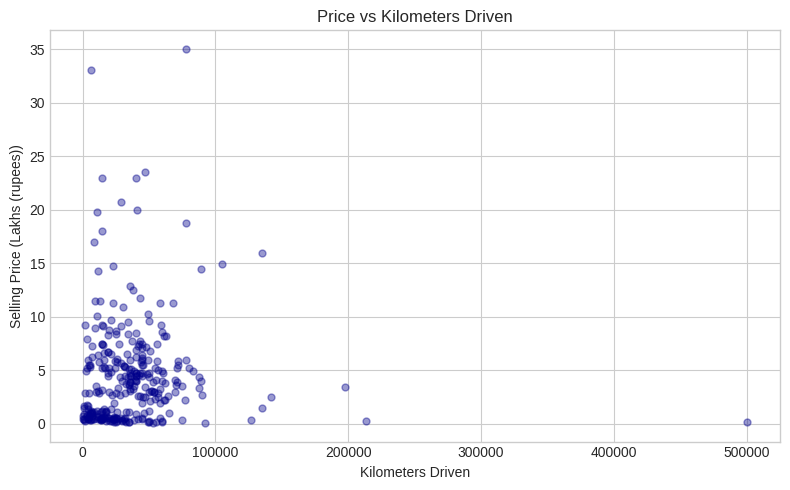

In [21]:
#Selling Price vs Driven KMs
plt.figure(figsize=(8, 5))
plt.scatter(df['Driven_kms'], df['Selling_Price'],
            alpha=0.4, color='darkblue', s=25)
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs (rupees))')
plt.title('Price vs Kilometers Driven')
plt.tight_layout()
plt.show()

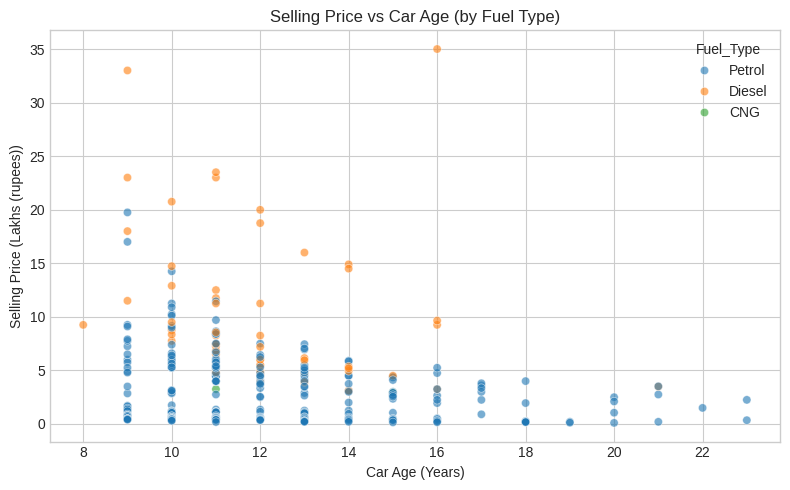

In [22]:
#Selling Price vs Car Age
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', hue='Fuel_Type', data=df, alpha=0.6)
plt.title('Selling Price vs Car Age (by Fuel Type)')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs (rupees))')
plt.tight_layout()
plt.show()

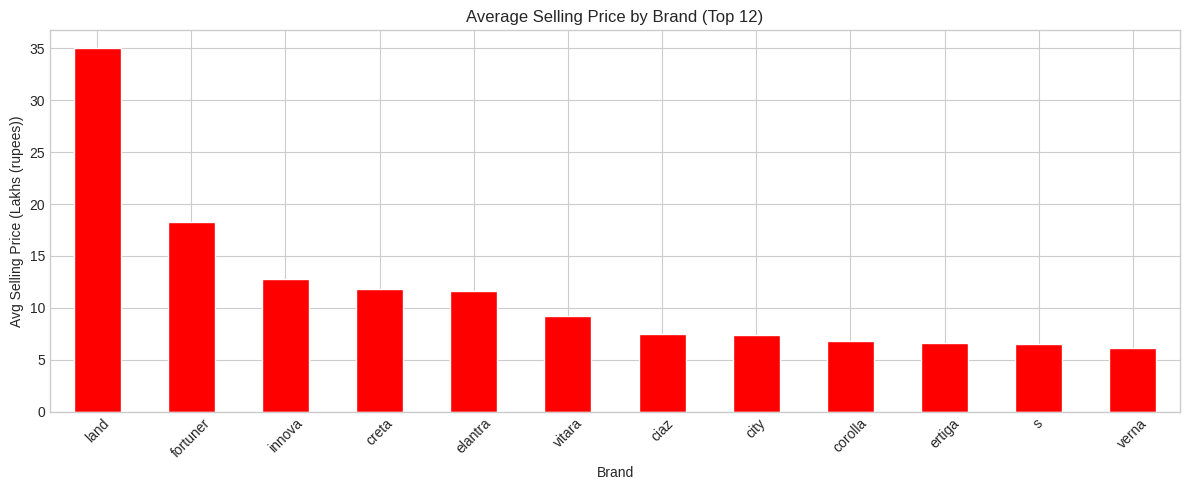

In [23]:
#Average selling price by brand
brand_price = df.groupby('Brand')['Selling_Price'].mean()\
                .sort_values(ascending=False).head(12)
brand_price.plot(kind='bar', figsize=(12, 5),
                 color='red', edgecolor='white')
plt.title('Average Selling Price by Brand (Top 12)')
plt.ylabel('Avg Selling Price (Lakhs (rupees))')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

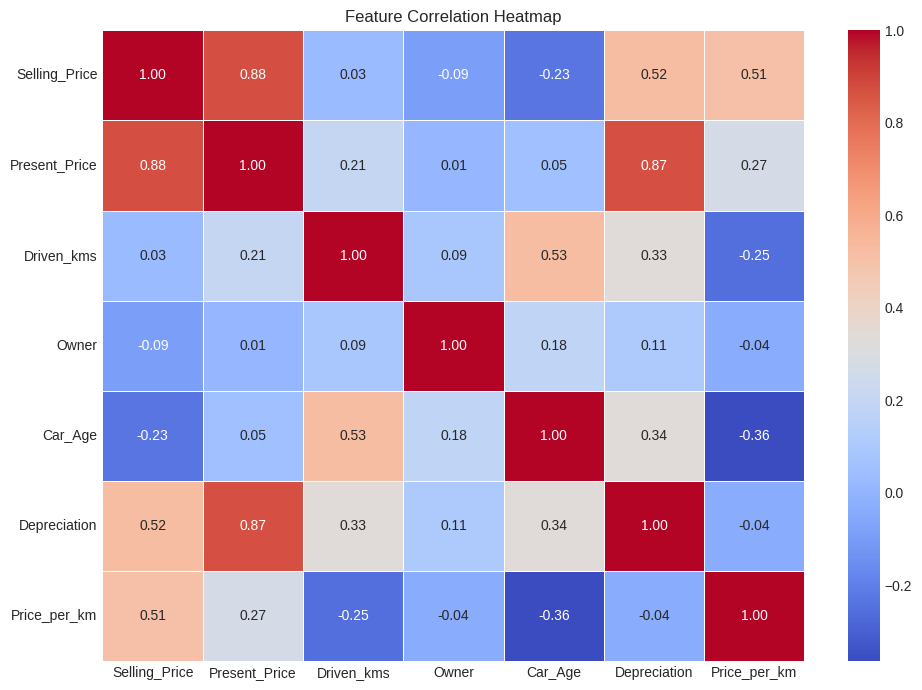

In [24]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include='number').columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Encoding Categorical Columns**

In [25]:
print("\nBefore encoding:")
print(df[['Fuel_Type', 'Selling_type', 'Transmission']].head(3))


Before encoding:
  Fuel_Type Selling_type Transmission
0    Petrol       Dealer       Manual
1    Diesel       Dealer       Manual
2    Petrol       Dealer       Manual


In [26]:
le = LabelEncoder()
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Brand']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nAfter encoding:")
print(df[['Fuel_Type', 'Selling_type', 'Transmission']].head(3))


After encoding:
   Fuel_Type  Selling_type  Transmission
0          2             0             1
1          1             0             1
2          2             0             1


In [27]:
#Apply log to the Selling Price
df['Selling_Price'] = np.log1p(df['Selling_Price'])

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(f"\nFeatures used: {X.columns.tolist()}")
print(f"Total features: {X.shape[1]}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


Features used: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Brand', 'Car_Age', 'Depreciation', 'Price_per_km']
Total features: 10


**Training the Models**

In [29]:
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}

    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression:
  MAE:  0.1899
  RMSE: 0.3020
  R²:   0.8603

Random Forest:
  MAE:  0.1247
  RMSE: 0.2560
  R²:   0.8997

Gradient Boosting:
  MAE:  0.1061
  RMSE: 0.1981
  R²:   0.9399


**Model Comparison**

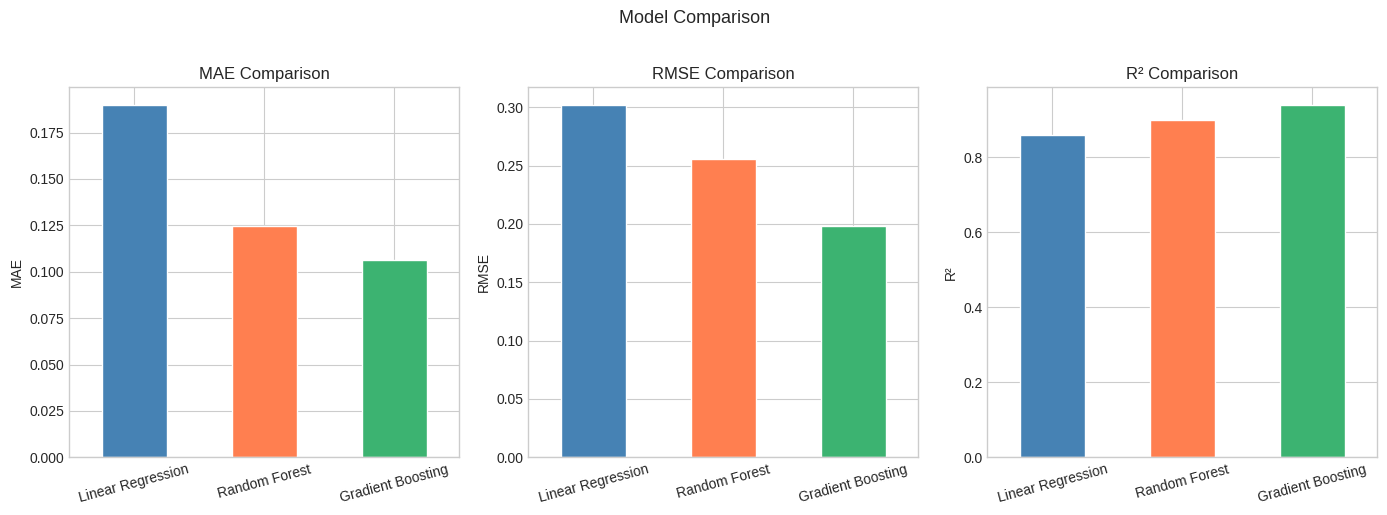

In [30]:
results_df = pd.DataFrame(results).T
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    results_df[metric].plot(kind='bar', ax=axes[i],
                             color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xticklabels(results_df.index, rotation=15)
    axes[i].set_ylabel(metric)

plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Best Model**

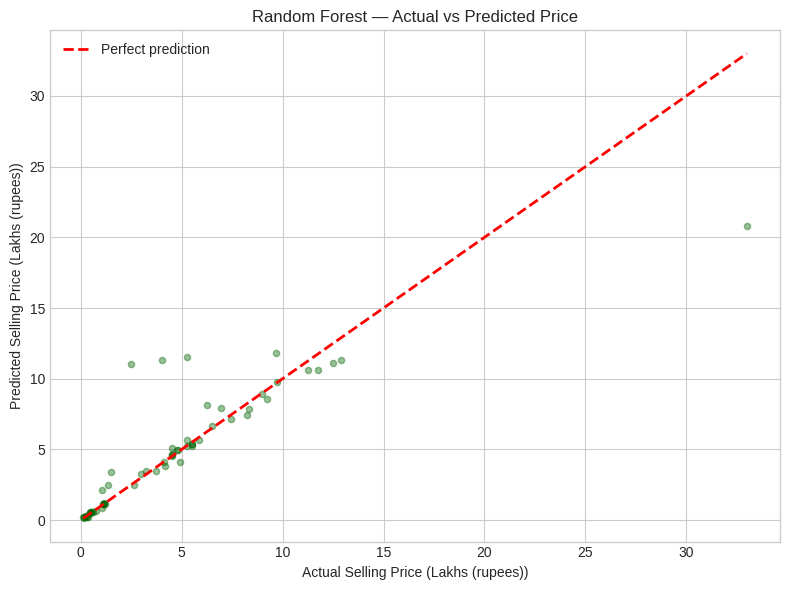

In [33]:
best_preds = predictions['Random Forest']

# Convert log price back to actual lakhs
actual_price    = np.expm1(y_test.values)
predicted_price = np.expm1(best_preds)

plt.figure(figsize=(8, 6))
plt.scatter(actual_price, predicted_price,
            alpha=0.4, color='darkgreen', s=20)
plt.plot([actual_price.min(), actual_price.max()],
         [actual_price.min(), actual_price.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Selling Price (Lakhs (rupees))')
plt.ylabel('Predicted Selling Price (Lakhs (rupees))')
plt.title('Random Forest — Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

**Which Feature has a greater importance?**

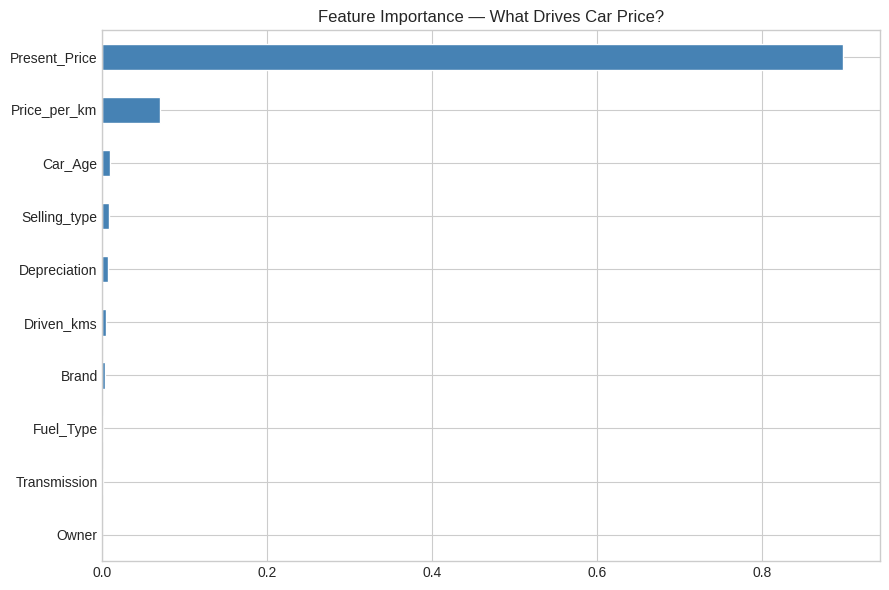

In [34]:
rf_model = models['Random Forest']
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(kind='barh', figsize=(9, 6),
              color='steelblue', edgecolor='white')
plt.title('Feature Importance — What Drives Car Price?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**FINAL SUMMARY**

In [35]:
best_r2 = results['Random Forest']['R²']

print("=" * 50)
print("         CAR PRICE PREDICTION SUMMARY")
print("=" * 50)
print(f"Total cars analyzed:    {len(df)}")
print(f"Features used:          {X.shape[1]}")
print(f"Best Model:             Random Forest")
print(f"R² Score:               {best_r2} ({best_r2*100:.1f}% variance explained)")
print(f"Avg prediction error:   ₹{results['Random Forest']['MAE']:.4f} Lakhs (log scale)")
print("=" * 50)

         CAR PRICE PREDICTION SUMMARY
Total cars analyzed:    299
Features used:          10
Best Model:             Random Forest
R² Score:               0.8997 (90.0% variance explained)
Avg prediction error:   ₹0.1247 Lakhs (log scale)
